# Estimacion espectra usando welch

Para estimar la densidad espectral de potencia (PSD) de las señales ECG, se empleó el método de Welch con una frecuencia de muestreo de 500 Hz, un tamaño de segmento (nperseg) de 1024 muestras y los parámetros por defecto de ventana (window='hann') y solapamiento (noverlap=512, equivalente al 50% del segmento). La elección de nperseg=1024 ofrece un balance adecuado entre resolución en frecuencia (~0.49 Hz por bin) y cantidad de segmentos disponibles para promediado (~5 por señal de 5000 muestras), lo cual permite una estimación espectral suficientemente detallada y estable. La ventana de Hann, al ser suavizada, reduce el efecto de fugas espectrales entre bandas de frecuencia, y el solapamiento del 50% mejora la reducción de la varianza sin afectar significativamente la independencia entre los segmentos. Esta configuración resulta apropiada para señales biológicas como el ECG, donde es importante mantener un equilibrio entre nitidez espectral y robustez frente al ruido.


Se encontraron 10646 archivos.


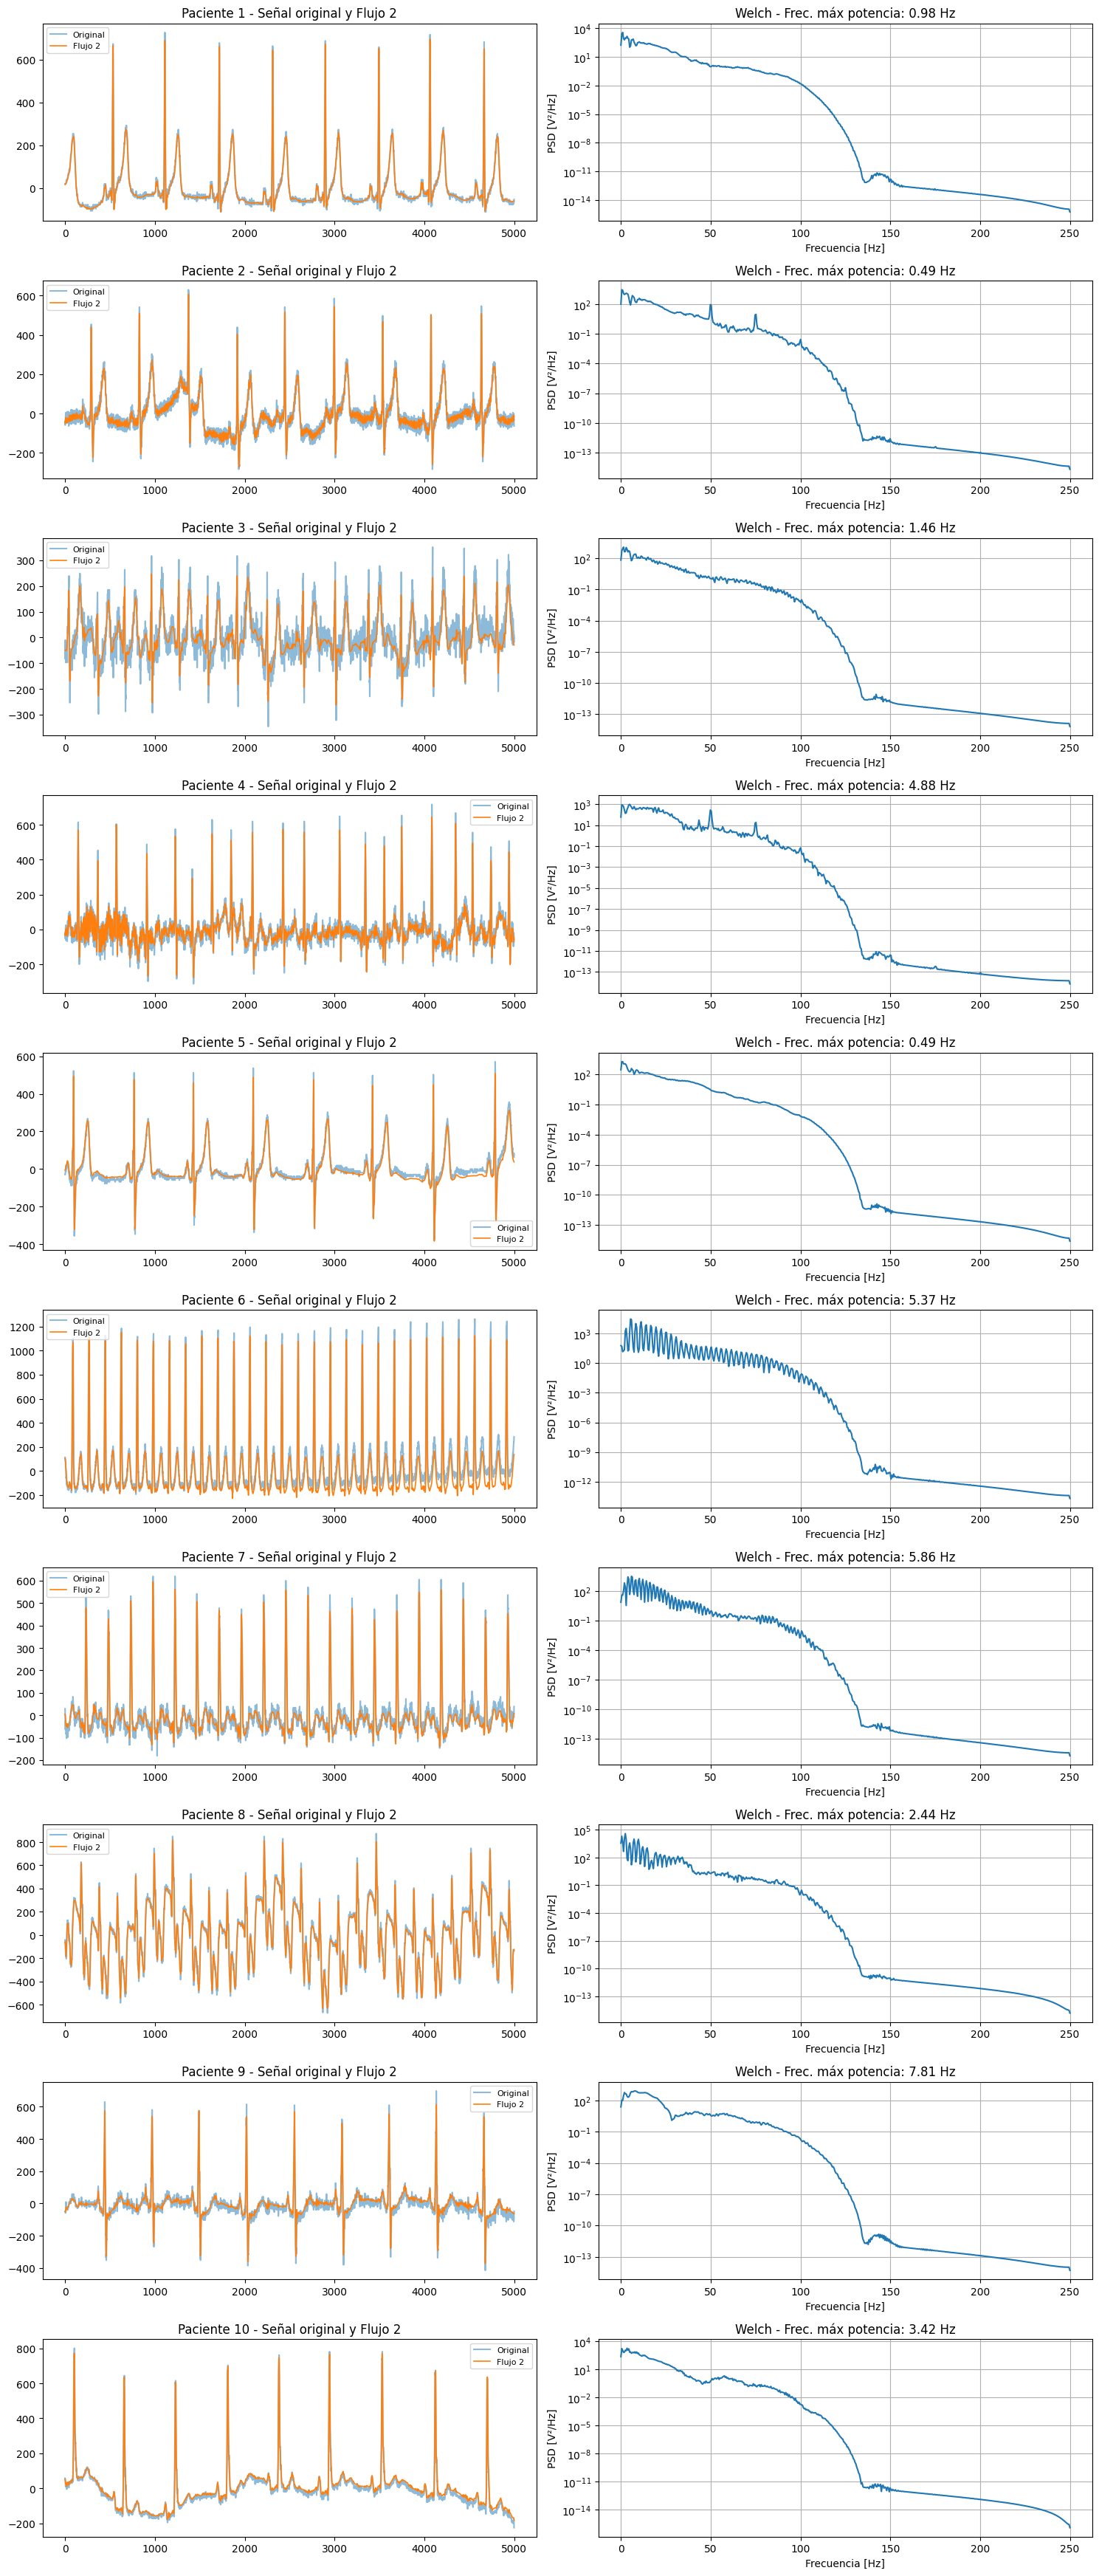

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, firwin, detrend, welch
from statsmodels.nonparametric.smoothers_lowess import lowess
from skimage.restoration import denoise_nl_means
import pywt
import pandas as pd
import glob

# Cargar lista de archivos
ruta_carpeta = r'.\Datos\ECGData\*.csv'
lista_archivos = glob.glob(ruta_carpeta)

print(f"Se encontraron {len(lista_archivos)} archivos.")

# Seleccionar 10 archivos aleatorios
np.random.seed(65)
pacientes_seleccionados = np.random.choice(lista_archivos, size=10, replace=False)

def cargar_derivacion_II(ruta_archivo):
    data = np.genfromtxt(ruta_archivo, delimiter=',', skip_header=1)
    lead_II = data[:, 1]
    return lead_II

def filtrar_wavelet(signal, wavelet_name='sym4', nivel=8):
    coeffs = pywt.wavedec(signal, wavelet_name, level=nivel)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_filt = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs_filt, wavelet_name)

def calcular_numtaps_hamming(fs, delta_f):
    return int(fs / delta_f)

def fir_lowpass_filter(data, cutoff, fs, numtaps, window='hamming'):
    nyq_rate = fs / 2.0
    fir_coeff = firwin(numtaps, cutoff / nyq_rate, window=window)
    return filtfilt(fir_coeff, 1.0, data)

# Flujo 2
def flujo_2(ecg, fs=250, cutoff=50, delta_f_real=10, wavelet_name='sym4', nivel=8):
    ecg_detrended = detrend(ecg)
    ecg_filtrada_wavelet = filtrar_wavelet(ecg_detrended, wavelet_name=wavelet_name, nivel=nivel)
    numtaps = calcular_numtaps_hamming(fs, delta_f_real)
    ecg_filtrada_final = fir_lowpass_filter(ecg_filtrada_wavelet, cutoff, fs, numtaps=numtaps, window='hamming')
    return ecg_filtrada_final

# Preparar la figura con 10 filas, 2 columnas (izquierda: señal, derecha: PSD)
fig, axes = plt.subplots(10, 2, figsize=(15, 35))
fs = 250  # Frecuencia de muestreo
nperseg=1024
noverlap = nperseg // 2
frec= []

for i, archivo in enumerate(pacientes_seleccionados):
    ecg_signal = cargar_derivacion_II(archivo)
    f2 = flujo_2(ecg_signal, fs=fs)

    # Gráfica izquierda: señal original y procesada (Flujo 2)
    axes[i, 0].plot(ecg_signal, label='Original', alpha=0.5)
    axes[i, 0].plot(f2, label='Flujo 2', linewidth=1.2)
    axes[i, 0].set_title(f'Paciente {i+1} - Señal original y Flujo 2')
    axes[i, 0].legend(fontsize=8)

    # Welch
    freqs, psd = welch(f2, fs=500, nperseg=1024,noverlap=noverlap)
    freq_max_power = freqs[np.argmax(psd)]

    # Guardar la frecuencia de máxima potencia      
    frec.append(freq_max_power)
    

    # Gráfica derecha: PSD
    axes[i, 1].semilogy(freqs, psd)
    axes[i, 1].set_title(f'Welch - Frec. máx potencia: {freq_max_power:.2f} Hz')
    axes[i, 1].set_xlabel('Frecuencia [Hz]')
    axes[i, 1].set_ylabel('PSD [V²/Hz]')
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

# Filtrado y extraccion de la frecuencia de maxima potencia flujo 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, firwin, detrend, welch
from statsmodels.nonparametric.smoothers_lowess import lowess
from skimage.restoration import denoise_nl_means
import os
import pywt
import pandas as pd


def filtrar_wavelet(signal, wavelet_name='sym4', nivel=8):
    coeffs = pywt.wavedec(signal, wavelet_name, level=nivel)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_filt = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs_filt, wavelet_name)

def calcular_numtaps_hamming(fs, delta_f):
    return int(fs / delta_f)

def fir_lowpass_filter(data, cutoff, fs, numtaps, window='hamming'):
    nyq_rate = fs / 2.0
    fir_coeff = firwin(numtaps, cutoff / nyq_rate, window=window)
    return filtfilt(fir_coeff, 1.0, data)

# Flujo 2
def flujo_2(ecg, fs=250, cutoff=50, delta_f_real=10, wavelet_name='sym4', nivel=8):
    ecg_detrended = detrend(ecg)
    ecg_filtrada_wavelet = filtrar_wavelet(ecg_detrended, wavelet_name=wavelet_name, nivel=nivel)
    numtaps = calcular_numtaps_hamming(fs, delta_f_real)
    ecg_filtrada_final = fir_lowpass_filter(ecg_filtrada_wavelet, cutoff, fs, numtaps=numtaps, window='hamming')
    return ecg_filtrada_final


                              # Número de coeficientes DCT a extraer por latido

datos = pd.read_excel(r'C:\Users\ctama\OneDrive\Desktop\Bioseñales\Proyecto 3\Datos\Datos filtrados.xlsx') # Este es el codigo de pandas para leer la base de datos del proyecto 1
# === Ruta ECG === Ruta base donde están almacenados los archivos de señales ECG
directorio_base = r'C:\Users\ctama\OneDrive\Desktop\Bioseñales\Proyecto 3\Datos\ECGData'

nperseg=1024
noverlap = nperseg // 2


# Lista para almacenar resultados
resultados = []

# === Procesamiento por archivo ===
for i, nombre_archivo in enumerate(datos['FileName']):
    try:
        # Cargamos la señal desde archivo CSV
        ruta = os.path.join(directorio_base, f"{nombre_archivo}.csv")
        senal = pd.read_csv(ruta, delimiter=',', names=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'],header=0)

        # Verificamos que exista la derivación II
        if 'II' not in senal.columns:
            print(f"❌ {nombre_archivo}: columna 'II' no encontrada.")
            continue

        # Extraemos la señal de la derivación II
        ecg = senal['II'].values

        # Procesamiento (flujo 2)
        f2 = flujo_2(ecg)

        # Welch
        freqs, psd = welch(f2, fs=500, nperseg=1024, noverlap=512)
        freq_max_power = freqs[np.argmax(psd)]

        # Agregar resultado a la lista
        resultados.append({
            'FileName': nombre_archivo,
            'Rhythm': datos.loc[i, 'Rhythm'],
            'FreqMaxPower': freq_max_power
        })

    except Exception as e:
        print(f"⚠️ Error en {nombre_archivo}: {e}")

# Convertir la lista de diccionarios a DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar los primeros registros para verificación
print(df_resultados.head())

                     FileName Rhythm  FreqMaxPower
0  MUSE_20180712_160452_75000   AFIB      3.417969
1  MUSE_20180118_131905_87000   AFIB      2.441406
2  MUSE_20180114_071444_05000   AFIB      4.394531
3  MUSE_20180114_132956_24000   AFIB      0.488281
4  MUSE_20180118_124852_18000   AFIB      8.300781


# Extraccion maxima frecuencia de potencia datos Denoised

In [4]:
datos = pd.read_excel(r'C:\Users\ctama\OneDrive\Desktop\Bioseñales\Proyecto 3\Datos\Datos filtrados.xlsx') # Este es el codigo de pandas para leer la base de datos del proyecto 1
# === Ruta ECG === Ruta base donde están almacenados los archivos de señales ECG
directorio_base = r'C:\Users\ctama\OneDrive\Desktop\Bioseñales\Proyecto 3\Datos\ECGDataDenoised'


# Lista para almacenar resultados
resultados_pros = []

# === Procesamiento por archivo ===
for i, nombre_archivo in enumerate(datos['FileName']):
    try:
        # Cargamos la señal desde archivo CSV
        ruta = os.path.join(directorio_base, f"{nombre_archivo}.csv")
        senal = pd.read_csv(ruta, delimiter=',', names=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'])

        # Verificamos que exista la derivación II
        if 'II' not in senal.columns:
            print(f"❌ {nombre_archivo}: columna 'II' no encontrada.")
            continue

        # Extraemos la señal de la derivación II
        ecg = senal['II'].values

        # Welch
        freqs, psd = welch(ecg, fs=500, nperseg=1024, noverlap=512)
        freq_max_power = freqs[np.argmax(psd)]

        # Agregar resultado a la lista
        resultados_pros.append({
            'FileName': nombre_archivo,
            'Rhythm': datos.loc[i, 'Rhythm'],
            'FreqMaxPower': freq_max_power
        })

    except Exception as e:
        print(f"⚠️ Error en {nombre_archivo}: {e}")

# Convertir la lista de diccionarios a DataFrame
df_resultados_pros = pd.DataFrame(resultados_pros)

# Mostrar los primeros registros para verificación
print(df_resultados_pros.head())

                     FileName Rhythm  FreqMaxPower
0  MUSE_20180712_160452_75000   AFIB      3.417969
1  MUSE_20180118_131905_87000   AFIB      2.441406
2  MUSE_20180114_071444_05000   AFIB      4.394531
3  MUSE_20180114_132956_24000   AFIB      1.464844
4  MUSE_20180118_124852_18000   AFIB      8.300781


In [6]:
df_resultados['FreqMaxPower']

0       3.417969
1       2.441406
2       4.394531
3       0.488281
4       8.300781
          ...   
7475    3.906250
7476    0.488281
7477    4.882812
7478    4.882812
7479    1.953125
Name: FreqMaxPower, Length: 7480, dtype: float64

In [5]:
df_resultados_pros['FreqMaxPower']

0       3.417969
1       2.441406
2       4.394531
3       1.464844
4       8.300781
          ...   
7475    3.906250
7476    3.417969
7477    4.882812
7478    4.882812
7479    2.441406
Name: FreqMaxPower, Length: 7480, dtype: float64

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway  # ANOVA
from scipy.stats import kruskal  # Prueba no paramétrica opcional
from scipy.stats import ttest_ind

C:\Users\ctama\AppData\Local\Temp\ipykernel_44436\4117335452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_resultados, x='Rhythm', y='FreqMaxPower', palette='Pastel1')
C:\Users\ctama\AppData\Local\Temp\ipykernel_44436\4117335452.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_resultados_pros, x='Rhythm', y='FreqMaxPower', palette='Pastel2')


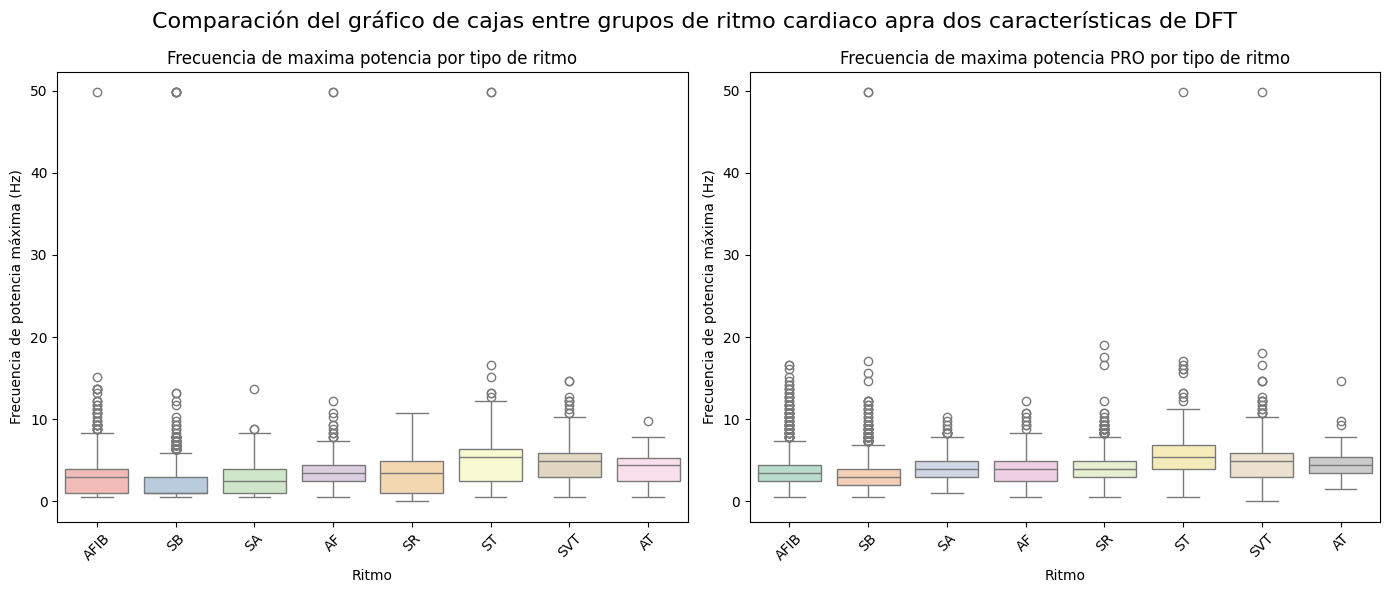

In [30]:
# Gráficos para todos los ritmos disponibles, no solo AFIB y SR
plt.figure(figsize=(14, 6))

# Boxplot de frecuencia pico
plt.subplot(1, 2, 1)
sns.boxplot(data=df_resultados, x='Rhythm', y='FreqMaxPower', palette='Pastel1')
plt.title('Frecuencia de maxima potencia por tipo de ritmo')
plt.ylabel('Frecuencia de potencia máxima (Hz)')
plt.xlabel('Ritmo')
plt.xticks(rotation=45)

# Boxplot de energía total
plt.subplot(1, 2, 2)
sns.boxplot(data=df_resultados_pros, x='Rhythm', y='FreqMaxPower', palette='Pastel2')
plt.title('Frecuencia de maxima potencia PRO por tipo de ritmo')
plt.ylabel('Frecuencia de potencia máxima (Hz)')
plt.xlabel('Ritmo')
plt.xticks(rotation=45)

plt.suptitle("Comparación del gráfico de cajas entre grupos de ritmo cardiaco apra dos características de DFT", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# Recargar archivos y repetir el análisis tras reinicio del entorno
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, shapiro

# Filtrar solo los ritmos AFIB y SR para análisis comparativo
df_filtrado = df_resultados[df_resultados['Rhythm'].isin(['AFIB', 'SR'])].copy()
df_filtrado_pro = df_resultados_pros[df_resultados_pros['Rhythm'].isin(['AFIB', 'SR'])].copy()

# Convertir columnas relevantes a tipo numérico
df_filtrado['FreqMaxPower'] = pd.to_numeric(df_filtrado['FreqMaxPower'], errors='coerce')
df_filtrado_pro['FreqMaxPower'] = pd.to_numeric(df_filtrado_pro['FreqMaxPower'], errors='coerce')

# Extraer los datos necesarios para las pruebas estadísticas
frecuencia_afib = df_filtrado[df_filtrado['Rhythm'] == 'AFIB']['FreqMaxPower'].dropna()
frecuencia_afib_pro = df_filtrado_pro[df_filtrado_pro['Rhythm'] == 'AFIB']['FreqMaxPower'].dropna()
frecuencia_sr = df_filtrado[df_filtrado['Rhythm'] == 'SR']['FreqMaxPower'].dropna()
frecuencia_sr_pro = df_filtrado_pro[df_filtrado_pro['Rhythm'] == 'SR']['FreqMaxPower'].dropna()


# Script separado para evaluar la normalidad y dar mensajes interpretativos

# Prueba de normalidad Shapiro-Wilk
shapiro_fp_afib = shapiro(frecuencia_afib)
shapiro_fp_sr = shapiro(frecuencia_sr)
shapiro_fp_afib_pro = shapiro(frecuencia_afib_pro)
shapiro_fp_sr_pro = shapiro(frecuencia_sr_pro)

# Función para interpretar la normalidad
def interpretar_normalidad_con_p(nombre_variable, resultado_afib, resultado_sr):
    print(f"Evaluando normalidad para: {nombre_variable}")
    print(f" - AFIB: p-value = {resultado_afib.pvalue:.5e}")
    if resultado_afib.pvalue < 0.05:
        print("   → No sigue una distribución normal (p < 0.05)")
    else:
        print("   → Sigue una distribución normal (p ≥ 0.05)")

    print(f" - SR:   p-value = {resultado_sr.pvalue:.5e}")
    if resultado_sr.pvalue < 0.05:
        print("   → No sigue una distribución normal (p < 0.05)")
    else:
        print("   → Sigue una distribución normal (p ≥ 0.05)")
    print()

# Ejecutar interpretación con p-valor
interpretar_normalidad_con_p('FreqMaxPower', shapiro_fp_afib, shapiro_fp_sr)
interpretar_normalidad_con_p('FreqMaxPower Pro', shapiro_fp_afib_pro, shapiro_fp_sr_pro)

Evaluando normalidad para: FreqMaxPower
 - AFIB: p-value = 1.55290e-39
   → No sigue una distribución normal (p < 0.05)
 - SR:   p-value = 5.25785e-25
   → No sigue una distribución normal (p < 0.05)

Evaluando normalidad para: FreqMaxPower Pro
 - AFIB: p-value = 1.35184e-33
   → No sigue una distribución normal (p < 0.05)
 - SR:   p-value = 2.11537e-27
   → No sigue una distribución normal (p < 0.05)



In [19]:
# Calcular prueba de Mann-Whitney U
mwu_fp = mannwhitneyu(frecuencia_afib, frecuencia_sr, alternative='two-sided')
mwu_Pro = mannwhitneyu(frecuencia_afib_pro, frecuencia_sr_pro, alternative='two-sided')

# Función para mostrar resultados
def interpretar_mannwhitney(nombre_variable, resultado_mwu):
    print(f"Prueba Mann-Whitney U para: {nombre_variable}")
    print(f" - Estadístico U = {resultado_mwu.statistic:.0f}")
    print(f" - p-value = {resultado_mwu.pvalue:.5e}")
    if resultado_mwu.pvalue < 0.05:
        print("   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)")
    else:
        print("   → No hay diferencia estadísticamente significativa entre los grupos (p ≥ 0.05)")
    print()

# Ejecutar función
interpretar_mannwhitney('FreqMaxPower', mwu_fp)
interpretar_mannwhitney('FreqMaxPower Pro', mwu_Pro)

Prueba Mann-Whitney U para: FreqMaxPower
 - Estadístico U = 618642
 - p-value = 5.21845e-11
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)

Prueba Mann-Whitney U para: FreqMaxPower Pro
 - Estadístico U = 579006
 - p-value = 7.77609e-19
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)



In [21]:
from scipy.stats import shapiro

# Filtrar todos los ritmos de interés
df_filtrado = df_resultados[df_resultados['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT'])].copy()
df_filtrado_pro = df_resultados_pros[df_resultados_pros['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT'])].copy()

# Convertir columnas relevantes
df_filtrado['FreqMaxPower'] = pd.to_numeric(df_filtrado['FreqMaxPower'], errors='coerce')
df_filtrado_pro['FreqMaxPower'] = pd.to_numeric(df_filtrado_pro['FreqMaxPower'], errors='coerce')

# Definir comparaciones
comparaciones = [
    ('SR', 'SB'),
    ('ST', 'SVT'),
    ('SB', 'ST')
]

# Función para imprimir resultados de la prueba de normalidad
def interpretar_normalidad_con_p(nombre_variable, grupo1_nombre, datos1, grupo2_nombre, datos2):
    print(f"Evaluando normalidad para: {nombre_variable} entre {grupo1_nombre} y {grupo2_nombre}")
    resultado1 = shapiro(datos1)
    resultado2 = shapiro(datos2)

    print(f" - {grupo1_nombre}: p-value = {resultado1.pvalue:.5e}")
    if resultado1.pvalue < 0.05:
        print("   → No sigue una distribución normal (p < 0.05)")
    else:
        print("   → Sigue una distribución normal (p ≥ 0.05)")

    print(f" - {grupo2_nombre}: p-value = {resultado2.pvalue:.5e}")
    if resultado2.pvalue < 0.05:
        print("   → No sigue una distribución normal (p < 0.05)")
    else:
        print("   → Sigue una distribución normal (p ≥ 0.05)")
    print()

# Ejecutar comparaciones
for grupo1, grupo2 in comparaciones:
    frecuencia1 = df_filtrado[df_filtrado['Rhythm'] == grupo1]['FreqMaxPower'].dropna()
    frecuencia2 = df_filtrado[df_filtrado['Rhythm'] == grupo2]['FreqMaxPower'].dropna()
    interpretar_normalidad_con_p('FreqMaxPower', grupo1, frecuencia1, grupo2, frecuencia2)

    energia1 = df_filtrado_pro[df_filtrado_pro['Rhythm'] == grupo1]['FreqMaxPower'].dropna()
    energia2 = df_filtrado_pro[df_filtrado_pro['Rhythm'] == grupo2]['FreqMaxPower'].dropna()
    interpretar_normalidad_con_p('FreqMaxPower Pro', grupo1, energia1, grupo2, energia2)

    print(" ")

Evaluando normalidad para: FreqMaxPower entre SR y SB
 - SR: p-value = 5.25785e-25
   → No sigue una distribución normal (p < 0.05)
 - SB: p-value = 2.15303e-68
   → No sigue una distribución normal (p < 0.05)

Evaluando normalidad para: FreqMaxPower Pro entre SR y SB
 - SR: p-value = 2.11537e-27
   → No sigue una distribución normal (p < 0.05)
 - SB: p-value = 1.39703e-57
   → No sigue una distribución normal (p < 0.05)

 
Evaluando normalidad para: FreqMaxPower entre ST y SVT
 - ST: p-value = 1.24594e-40
   → No sigue una distribución normal (p < 0.05)
 - SVT: p-value = 4.09349e-16
   → No sigue una distribución normal (p < 0.05)

Evaluando normalidad para: FreqMaxPower Pro entre ST y SVT
 - ST: p-value = 3.51813e-37
   → No sigue una distribución normal (p < 0.05)
 - SVT: p-value = 5.77927e-30
   → No sigue una distribución normal (p < 0.05)

 
Evaluando normalidad para: FreqMaxPower entre SB y ST
 - SB: p-value = 2.15303e-68
   → No sigue una distribución normal (p < 0.05)
 - ST: p

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro


# Filtrar todos los ritmos de interés
df_filtrado = df_resultados[df_resultados['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT'])].copy()
df_filtrado_pro = df_resultados_pros[df_resultados_pros['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT'])].copy()

# Convertir columnas relevantes
df_filtrado['FreqMaxPower'] = pd.to_numeric(df_filtrado['FreqMaxPower'], errors='coerce')
df_filtrado_pro['FreqMaxPower'] = pd.to_numeric(df_filtrado_pro['FreqMaxPower'], errors='coerce')

# Definir comparaciones
comparaciones = [
    ('SR', 'SB'),
    ('ST', 'SVT'),
    ('SB', 'ST')
]

# Función para mostrar resultados de Mann-Whitney
def interpretar_mannwhitney(grupo1_nombre, grupo2_nombre, nombre_variable, datos1, datos2):
    resultado_mwu = mannwhitneyu(datos1, datos2, alternative='two-sided')
    print(f"Prueba Mann-Whitney U para: {nombre_variable} entre {grupo1_nombre} y {grupo2_nombre}")
    print(f" - Estadístico U = {resultado_mwu.statistic:.0f}")
    print(f" - p-value = {resultado_mwu.pvalue:.5e}")
    if resultado_mwu.pvalue < 0.05:
        print("   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)")
    else:
        print("   → No hay diferencia estadísticamente significativa entre los grupos (p ≥ 0.05)")
    print()

# Ejecutar para todas las comparaciones
for grupo1, grupo2 in comparaciones:
    frecuencia1 = df_filtrado[df_filtrado['Rhythm'] == grupo1]['FreqMaxPower'].dropna()
    frecuencia2 = df_filtrado[df_filtrado['Rhythm'] == grupo2]['FreqMaxPower'].dropna()
    interpretar_mannwhitney(grupo1, grupo2, 'FreqMaxPower', frecuencia1, frecuencia2)

    energia1 = df_filtrado_pro[df_filtrado_pro['Rhythm'] == grupo1]['FreqMaxPower'].dropna()
    energia2 = df_filtrado_pro[df_filtrado_pro['Rhythm'] == grupo2]['FreqMaxPower'].dropna()
    interpretar_mannwhitney(grupo1, grupo2, 'FreqMaxPower', energia1, energia2)

    print("")

Prueba Mann-Whitney U para: FreqMaxPower entre SR y SB
 - Estadístico U = 2722136
 - p-value = 1.03471e-104
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)

Prueba Mann-Whitney U para: FreqMaxPower Pro entre SR y SB
 - Estadístico U = 2729693
 - p-value = 8.71930e-103
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)


Prueba Mann-Whitney U para: FreqMaxPower entre ST y SVT
 - Estadístico U = 348447
 - p-value = 4.55293e-04
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)

Prueba Mann-Whitney U para: FreqMaxPower Pro entre ST y SVT
 - Estadístico U = 389460
 - p-value = 7.36816e-15
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)


Prueba Mann-Whitney U para: FreqMaxPower entre SB y ST
 - Estadístico U = 576678
 - p-value = 9.54153e-259
   → Hay diferencia estadísticamente significativa entre los grupos (p < 0.05)

Prueba Mann-Whitney U para: FreqMaxPower Pro entre SB

C:\Users\ctama\AppData\Local\Temp\ipykernel_44436\4271353989.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='Rhythm', y='FreqMaxPower', palette="Set2", inner="box", ax=axes[idx, 0])
C:\Users\ctama\AppData\Local\Temp\ipykernel_44436\4271353989.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp_pro, x='Rhythm', y='FreqMaxPower', palette="Set3", inner="box", ax=axes[idx, 1])
C:\Users\ctama\AppData\Local\Temp\ipykernel_44436\4271353989.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp

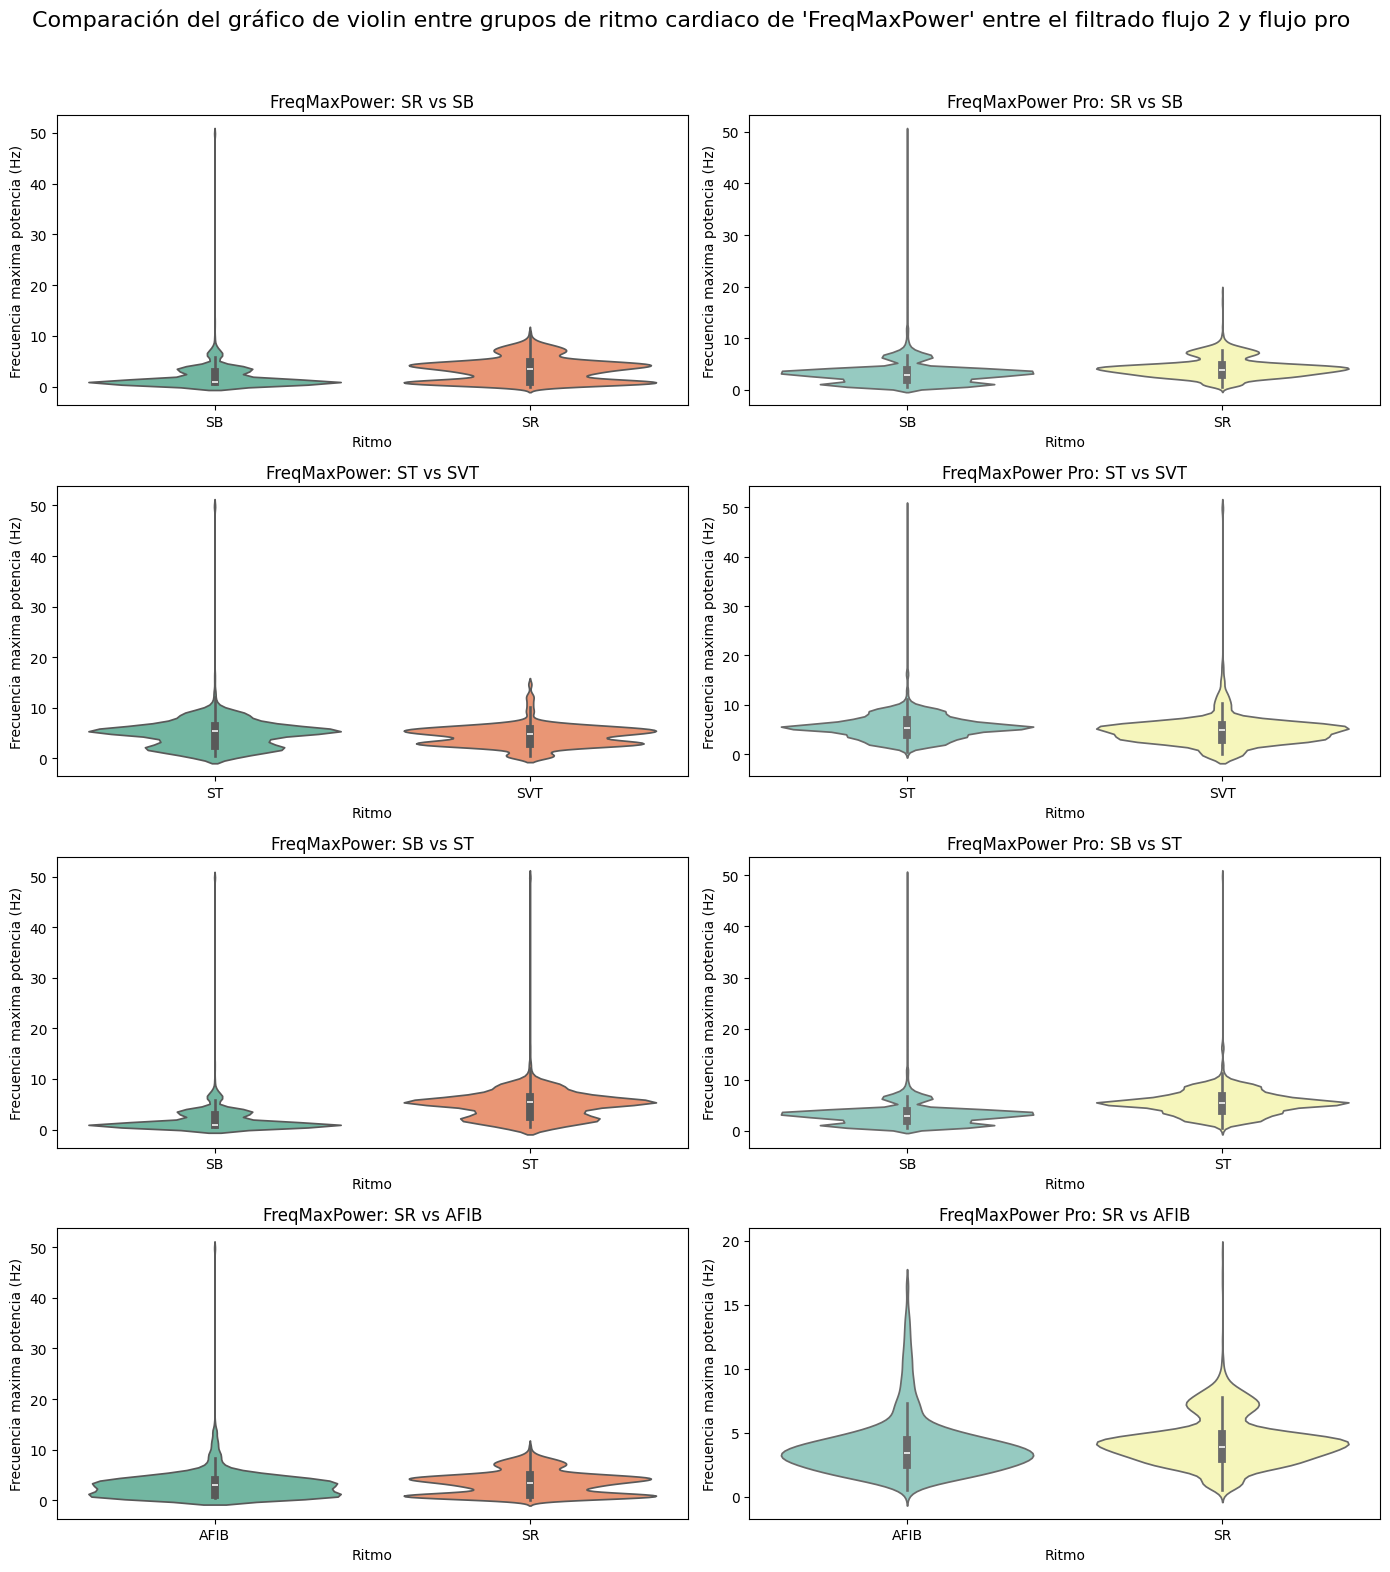

In [29]:
# Reimportar y volver a ejecutar tras reinicio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Filtrar todos los ritmos de interés
df_filtrado = df_resultados[df_resultados['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT','AFIB'])].copy()
df_filtrado_pro = df_resultados_pros[df_resultados_pros['Rhythm'].isin(['SR', 'SB', 'ST', 'SVT','AFIB'])].copy()

# Convertir columnas relevantes
df_filtrado['FreqMaxPower'] = pd.to_numeric(df_filtrado['FreqMaxPower'], errors='coerce')
df_filtrado_pro['FreqMaxPower'] = pd.to_numeric(df_filtrado_pro['FreqMaxPower'], errors='coerce')

# Agregar la comparación SR vs AFIB a las existentes
comparaciones = [
    ('SR', 'SB'),
    ('ST', 'SVT'),
    ('SB', 'ST'),
    ('SR', 'AFIB')
]

# Crear figura con todos los violin plots en filas
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
fig.suptitle("Comparación del gráfico de violin entre grupos de ritmo cardiaco de 'FreqMaxPower' entre el filtrado flujo 2 y flujo pro ", fontsize=16)

for idx, (grupo1, grupo2) in enumerate(comparaciones):
    df_temp = df_filtrado[df_filtrado['Rhythm'].isin([grupo1, grupo2])]
    df_temp_pro = df_filtrado_pro[df_filtrado_pro['Rhythm'].isin([grupo1, grupo2])]

    # Violin plot Frecuencia pico
    sns.violinplot(data=df_temp, x='Rhythm', y='FreqMaxPower', palette="Set2", inner="box", ax=axes[idx, 0])
    axes[idx, 0].set_title(f"FreqMaxPower: {grupo1} vs {grupo2}")
    axes[idx, 0].set_ylabel("Frecuencia maxima potencia (Hz)")
    axes[idx, 0].set_xlabel("Ritmo")

    # Violin plot Energía total
    sns.violinplot(data=df_temp_pro, x='Rhythm', y='FreqMaxPower', palette="Set3", inner="box", ax=axes[idx, 1])
    axes[idx, 1].set_title(f"FreqMaxPower Pro: {grupo1} vs {grupo2}")
    axes[idx, 1].set_ylabel("Frecuencia maxima potencia (Hz)")
    axes[idx, 1].set_xlabel("Ritmo")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

A partir del análisis comparativo de la frecuencia de máxima potencia (FreqMaxPower) extraída de señales ECG con filtrado usando el flujo 2 (no Pro) y filtrado realizado por profesionales de la base de datos ECGDataDenoised (Pro), se observa una clara diferencia en la distribución de los valores entre ambas versiones. Las gráficas de violín muestran que, en general, las señales procesadas profesionalmente presentan distribuciones más simétricas, compactas y con menor dispersión. En cambio, en la versión no Pro, las distribuciones tienden a ser más extendidas, con colas largas y presencia de múltiples picos, lo que sugiere una mayor influencia del ruido o artefactos no eliminados adecuadamente por el flujo automático.

Este patrón se ve reflejado particularmente en los pares de ritmos SB vs SR, ST vs SVT, y SB vs ST, donde en la versión Pro las curvas de densidad están mejor definidas y las medianas son más representativas del comportamiento del grupo. En ritmos como SR vs AFIB, también se nota que las curvas Pro presentan menos solapamiento entre los grupos, lo cual podría facilitar tareas de clasificación automática o interpretación clínica. Complementariamente, las gráficas de caja reafirman esta tendencia, ya que la versión Pro muestra una reducción en la cantidad de valores atípicos (outliers) exceptuando en el caso del SR que en el flujo 2 no posee ningun ourlie, continuando con la version Pro esta posee una disminución en el rango intercuartílico en varios ritmos. Esto sugiere una mayor homogeneidad de los datos tras el filtrado profesional.

Estos hallazgos visuales se ven respaldados por los resultados de las pruebas estadísticas Mann-Whitney U, las cuales confirman diferencias estadísticamente significativas entre los grupos de ritmos tanto en la versión Pro como en la no Pro. Por ejemplo, para el contraste entre SR y SB, se obtuvo un p-valor extremadamente bajo en ambas versiones (≈1e-104 en no Pro y ≈1e-103 en Pro), lo cual indica una separación robusta entre los grupos, independientemente del tipo de procesamiento. Sin embargo, en comparaciones como ST vs SVT, aunque ambas versiones arrojan significancia (p ≈ 4.5e-04 en no Pro y ≈7.3e-15 en Pro), la diferencia es mucho más marcada en la versión Pro, lo que sugiere una mayor capacidad discriminativa tras el filtrado profesional. Lo mismo ocurre en la comparación SB vs ST, donde el p-valor se reduce de ≈9.5e-259 (no Pro) a ≈1.9e-201 (Pro), manteniéndose altamente significativo pero con diferencias sutiles en la magnitud.

En conclusión, tanto el análisis gráfico como las pruebas estadísticas respaldan que el filtrado profesional mejora la calidad de las características espectrales, en particular la frecuencia de máxima potencia. Este preprocesamiento permite reducir la variabilidad intragrupo, mejorar la separación entre clases de ritmo y aumentar la robustez de los análisis posteriores. Aunque el flujo de trabajo 2 genera resultados útiles y significativos, aún muestra una mayor dispersión y presencia de ruido que puede afectar la precisión en tareas clínicas o computacionales.